In [2]:
# Импорты (уже есть в твоём коде, но проверим)
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from catboost import CatBoostRegressor, Pool
import optuna
import warnings
from sklearn.model_selection import KFold
import math
warnings.filterwarnings("ignore")

In [15]:
# Добавим в класс CFG
class CFG:
    TARGET = ['GGFM_f']
    # TARGET = ['gravity(mGal)']
    N_FOLDS = 5
    RANDOM_STATE = 3
    TEST_SIZE = 0.2
    VAL_SIZE = 0.2  # Для валидации внутри тренировочного набора
    
    COLORADO_PATH_TRAIN = './Data/Synt/Colorado_600_merge.csv'
    COLORADO_PATH_TEST = './Data/Synt/Colorado_60000_merge.csv'

    NSO_PATH_TRAIN = './Data/Synt/NSO_600_merge.csv'
    NSO_PATH_TEST = './Data/Synt/NSO_60000_merge.csv'

    COLORADO_TRUE_PATH_TRAIN = './Data/Colorado_gravity_data.dat'
    
    # Новые параметры для масштабирования
    SCALE_TARGET = False  # Включить масштабирование целевой переменной
    TARGET_SCALER = 'standard'  # 'standard', 'minmax', 'log'

In [4]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler

class DataLoader:
    def __init__(self, colorado: pd.DataFrame, nso: pd.DataFrame):
        self.colorado = colorado.copy()
        self.nso = nso
        self.log_features = []  # Список признаков для трансформации
        self.X = None
        self.y = None
        self.scaler = StandardScaler()  # Для нормализации признаков
        self.feature_names_ = []       # Для отслеживания имён признаков
        self.target_scaler = None
        self.feature_scaler = StandardScaler()

    @staticmethod
    def reduce_mem_usage(dataframe):
        """ 
        Уменьшает использование памяти dataframe путем преобразования типов данных
        с автоматическим пропуском временных столбцов
        """
        start_mem = dataframe.memory_usage().sum() / 1024**2
        print(f"Изначальное использование памяти: {start_mem:.2f} MB")
        
        for col in dataframe.columns:
            col_type = dataframe[col].dtype
            
            # Пропускаем временные столбцы и категориальные данные
            if str(col_type).startswith('datetime') or str(col_type) == 'category':
                continue
                
            if col_type != object:
                c_min = dataframe[col].min()
                c_max = dataframe[col].max()
                
                if str(col_type)[:3] == 'int':
                    if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                        dataframe[col] = dataframe[col].astype(np.int8)
                    elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                        dataframe[col] = dataframe[col].astype(np.int16)
                    elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                        dataframe[col] = dataframe[col].astype(np.int32)
                    elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                        dataframe[col] = dataframe[col].astype(np.int64)
                else:
                    if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                        dataframe[col] = dataframe[col].astype(np.float16)
                    elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                        dataframe[col] = dataframe[col].astype(np.float32)
                    else:
                        dataframe[col] = dataframe[col].astype(np.float64)
            else:
                # Оптимизация строковых столбцов
                dataframe[col] = dataframe[col].astype('category')
        
        end_mem = dataframe.memory_usage().sum() / 1024**2
        print(f"Итоговое использование памяти: {end_mem:.2f} MB")
        print(f"Экономия {(start_mem - end_mem) / start_mem * 100:.1f}%")
        
        return dataframe

    def add_spherical_coordinates(self):
        """Добавляет сферические координаты (x, y, z) как направляющие косинусы"""
        lat_rad = np.radians(self.colorado['Latitude (deg)'])
        lon_rad = np.radians(self.colorado['Longitude (deg)'])
        self.colorado['sph_x'] = np.cos(lat_rad) * np.cos(lon_rad)
        self.colorado['sph_y'] = np.cos(lat_rad) * np.sin(lon_rad)
        self.colorado['sph_z'] = np.sin(lat_rad)

    def add_cartesian_coordinates(self):
        """Добавляет декартовы координаты в метрах (с учётом радиуса и высоты)"""
        R = 6378137  # средний радиус Земли в метрах
        lat_rad = np.radians(self.colorado['Latitude (deg)'])
        lon_rad = np.radians(self.colorado['Longitude (deg)'])
        h = self.colorado['Height (m)']
        
        self.colorado['cart_x'] = (R + h) * np.cos(lat_rad) * np.cos(lon_rad)
        self.colorado['cart_y'] = (R + h) * np.cos(lat_rad) * np.sin(lon_rad)
        self.colorado['cart_z'] = (R + h) * np.sin(lat_rad)

    def add_polynomial_features(self):
        """Добавляет полиномиальные признаки"""
        self.colorado['lat2'] = self.colorado['Latitude (deg)'] ** 2
        self.colorado['lon2'] = self.colorado['Longitude (deg)'] ** 2
        self.colorado['lat_lon'] = self.colorado['Latitude (deg)'] * self.colorado['Longitude (deg)']
        self.colorado['height2'] = self.colorado['Height (m)'] ** 2


    def add_distance_from_center(self):
        """Добавляет расстояние до центра облака точек (полезно для гравитации)"""
        center_lat = self.colorado['Latitude (deg)'].mean()
        center_lon = self.colorado['Longitude (deg)'].mean()
        self.colorado['dist_from_center'] = np.sqrt(
            (self.colorado['Latitude (deg)'] - center_lat)**2 +
            (self.colorado['Longitude (deg)'] - center_lon)**2
        )

    def scale_target(self, y, inverse=False):
        """Масштабирование целевой переменной"""
        if CFG.SCALE_TARGET:
            if self.target_scaler is None and not inverse:
                if CFG.TARGET_SCALER == 'standard':
                    self.target_scaler = StandardScaler()
                    return self.target_scaler.fit_transform(y.reshape(-1, 1)).flatten()
                elif CFG.TARGET_SCALER == 'minmax':
                    self.target_scaler = MinMaxScaler()
                    return self.target_scaler.fit_transform(y.reshape(-1, 1)).flatten()
                elif CFG.TARGET_SCALER == 'log':
                    # Логарифмическое преобразование + сдвиг если есть отрицательные значения
                    min_val = y.min()
                    if min_val <= 0:
                        shift = abs(min_val) + 1
                        self.target_shift = shift
                        return np.log(y + shift)
                    else:
                        return np.log(y)
            elif inverse and self.target_scaler is not None:
                if CFG.TARGET_SCALER == 'standard':
                    return self.target_scaler.inverse_transform(y.reshape(-1, 1)).flatten()
                elif CFG.TARGET_SCALER == 'minmax':
                    return self.target_scaler.inverse_transform(y.reshape(-1, 1)).flatten()
                elif CFG.TARGET_SCALER == 'log':
                    if hasattr(self, 'target_shift'):
                        return np.exp(y) - self.target_shift
                    else:
                        return np.exp(y)
        return y

    def load(self, option='colorado'):
        """Загрузка и обогащение данных"""
        print(f'Loading data')
        print(f'Choosed option: {option}')

        if option == 'compare':
            self.colorado = self.colorado.merge(self.nso, left_on='latitude(deg)', right_on='lat(deg)', how='outer')
        elif option == 'colorado':
            pass
        else:
            raise ValueError("Option must be 'colorado' or 'compare'")

        # Шаг 1: Добавление признаков
        self.add_spherical_coordinates()
        self.add_cartesian_coordinates()
        self.add_polynomial_features()
        self.add_distance_from_center()

        # Шаг 2: Уменьшение потребления памяти
        self.colorado = self.reduce_mem_usage(self.colorado)

        # Шаг 3: Подготовка X и y с масштабированием
        self.y = self.colorado[CFG.TARGET].values.flatten()
        
        # Масштабирование целевой переменной
        self.y = self.scale_target(self.y)
        
        # Выбор признаков и масштабирование
        feature_columns = [
            col for col in self.colorado.columns 
            if col not in ['Latitude (deg)', 'Longitude (deg)', 'Height (m)', CFG.TARGET]
        ]
        self.X = self.colorado[feature_columns].values
        self.feature_names_ = feature_columns
        
        # Масштабирование признаков
        self.X = self.feature_scaler.fit_transform(self.X)
        
        print(f"Целевая переменная после масштабирования: min={self.y.min():.2f}, max={self.y.max():.2f}")

        print(f"Количество признаков: {self.X.shape[1]}")
        print(f"Форма X: {self.X.shape}, Форма y: {self.y.shape}")
        print(f"Признаки: {self.feature_names_}")

In [5]:
def normal_gravitational_potential_grs80(latitude_deg, height):
    """
    Вычисляет нормальный гравитационный потенциал V (в м²/с²)
    по широте и высоте над эллипсоидом GRS80,
    используя формулу:
        V = GM/r * [1 - J2*(a/r)^2 * 0.5*(3*sin²φ - 1)]
    Расстояние r вычисляется аналитически через геодезические параметры.

    Параметры:
        latitude_deg (float): геодезическая широта в градусах
        height (float): высота над эллипсоидом в метрах

    Возвращает:
        float: нормальный гравитационный потенциал V [м²/с²]
    """
    # Константы GRS80
    a = 6378137.0              # большая полуось, м
    GM = 3.986004418e14        # гравитационная постоянная, м³/с²
    J2 = 1.08263e-3            # коэффициент J2
    e2 = 0.00669438002290       # квадрат первого эксцентриситета

    # Переводим широту в радианы
    phi = np.radians(latitude_deg)
    sin_phi = np.sin(phi)
    cos_phi = np.cos(phi)
    sin2_phi = sin_phi * sin_phi

    # Радиус кривизны в первом вертикале
    N = a / np.sqrt(1 - e2 * sin2_phi)

    # Вычисляем r — расстояние от центра Земли до точки
    # через компоненты (аналитически, без векторов)
    term_eq = (N + height) * cos_phi
    term_pol = (N * (1 - e2) + height) * sin_phi
    r = np.sqrt(term_eq**2 + term_pol**2)

    # Вычисляем J2-член: (a/r)^2 * 0.5*(3*sin²φ - 1)
    a_over_r = a / r
    P2_term = 0.5 * (3 * sin2_phi - 1)  # полином Лежандра 2-го порядка
    j2_correction = J2 * (a_over_r ** 2) * P2_term

    # Гравитационный потенциал
    V = (GM / r) * (1 - j2_correction)

    return V

In [6]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

def calculate_laplacian_numeric(y_pred, coords, k=10, method='finite_difference_spherical'):
    """
    Вычисляет лапласиан ∇²Φ численно в каждой точке.
    
    Parameters:
    -----------
    y_pred : array (N,) — Прогнозные значения потенциала Φ
    coords : array (N, 3) — координаты [lat (deg), lon (deg), height (m)]
    k : int — количество ближайших соседей для оценки
    method : str — метод:
        - 'finite_difference_cartesian' — для близких точек в 3D
        - 'finite_difference_spherical' — с учётом сферической геометрии
        - 'inverse_distance' — простая оценка через среднее (твой текущий метод)

    Returns:
    --------
    laplacian : array (N,) — оценка ∇²Φ в каждой точке
    """
    N = len(y_pred)
    laplacian = np.zeros(N)
    
    # Преобразуем координаты
    lat = np.radians(coords[:, 0])  # в радианы
    lon = np.radians(coords[:, 1])
    h = coords[:, 2]  # высота в метрах
    
    # Переводим в декартовы координаты (в метрах)
    R = 6378137 + h  # радиус от центра Земли
    x = R * np.cos(lat) * np.cos(lon)
    y = R * np.sin(lat) * np.cos(lat)  # исправлено: cos(lat) для y
    z = R * np.sin(lat)
    xyz = np.stack([x, y, z], axis=1)

    nbrs = NearestNeighbors(n_neighbors=k+1).fit(xyz)  # +1 включая саму точку
    distances, indices = nbrs.kneighbors(xyz)

    for i in range(N):
        center_idx = i
        neighbor_indices = indices[i]  # включает саму точку
        neighbor_dists = distances[i]
        
        # Исключаем саму точку (расстояние 0)
        mask = neighbor_dists > 1e-5
        if mask.sum() < 6:
            laplacian[i] = 0
            continue

        j = neighbor_indices[mask]
        dx = xyz[j] - xyz[i]  # векторы к соседям (в метрах)
        df = y_pred[j] - y_pred[i]  # разница в потенциале

        if method == 'finite_difference_cartesian':
            # Оценка лапласиана через среднее отклонение
            # ∇²Φ ≈ (1/N) Σ (Φ_j - Φ_i) / (d_j²/6)  → из разложения Тейлора
            d_sq = np.sum(dx**2, axis=1) + 1e-8
            weights = 1 / d_sq
            weights /= weights.sum()
            laplacian[i] = 6 * np.dot(weights, df) / np.mean(d_sq)  # грубая оценка

        elif method == 'finite_difference_spherical':
            # Более точная оценка через локальную сферическую систему
            # Аппроксимируем как ∇²Φ ≈ (Σ w_j (Φ_j - Φ_i)) / σ²
            d = np.linalg.norm(dx, axis=1)
            sigma = np.mean(d)
            laplacian[i] = np.sum(df) / (sigma**2 + 1e-8)

        elif method == 'inverse_distance':
            # Твой текущий метод: ∇²Φ ≈ Φ_i - <Φ_соседей>
            weights = 1 / (neighbor_dists[mask] + 1e-8)
            weights /= weights.sum()
            avg_neighbor = np.dot(y_pred[j], weights)
            laplacian[i] = y_pred[i] - avg_neighbor  # может быть смещённым

    return laplacian

In [7]:
def combined_loss(y_true, y_pred, coords, alpha=0.1, k=10):
    """
    Комбинированная функция потерь: RMSE + условие Лапласа
    """
    # RMSE loss
    rmse_loss = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # Laplace constraint loss
    laplacian = calculate_laplacian_numeric(y_pred, coords, k=k)
    laplace_loss = np.mean(laplacian ** 2)
    
    total_loss = rmse_loss + alpha * laplace_loss
    
    return total_loss, rmse_loss, laplace_loss

def evaluate_model(model, X, y, coords, alpha=0.1):
    """
    Полная оценка модели с двумя метриками
    """
    y_pred = model.predict(X)
    
    total_loss, rmse_loss, laplace_loss = combined_loss(
        y, y_pred, coords, alpha=alpha
    )
    
    r2 = r2_score(y, y_pred)
    
    return {
        'total_loss': total_loss,
        'rmse': rmse_loss,
        'laplace_loss': laplace_loss,
        'r2': r2,
        'predictions': y_pred
    }

In [8]:
def cross_validate_with_laplace(features, target, coords, params, n_folds=5, alpha=0.1):
    """
    Кросс-валидация с проверкой обеих метрик
    """
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=CFG.RANDOM_STATE)
    
    results = {
        'total_loss': [],
        'rmse': [],
        'laplace_loss': [],
        'r2': [],
        'models': []
    }
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(features)):
        print(f"Fold {fold + 1}/{n_folds}")
        
        # Разделение данных
        X_train, X_val = features.iloc[train_idx], features.iloc[val_idx]
        y_train, y_val = target.iloc[train_idx], target.iloc[val_idx]
        coords_train, coords_val = coords[train_idx], coords[val_idx]
        
        # Создание Pool
        train_pool = Pool(X_train, y_train)
        val_pool = Pool(X_val, y_val)
        
        # Обучение модели
        model = CatBoostRegressor(**params)
        model.fit(
            train_pool,
            eval_set=val_pool,
            verbose=100,
            early_stopping_rounds=200
        )
        
        # Оценка на валидации
        eval_results = evaluate_model(model, X_val, y_val, coords_val, alpha=alpha)
        
        # Сохранение результатов
        for metric in ['total_loss', 'rmse', 'laplace_loss', 'r2']:
            results[metric].append(eval_results[metric])
        results['models'].append(model)
        
        print(f"Fold {fold + 1} - RMSE: {eval_results['rmse']:.4f}, "
              f"Laplace: {eval_results['laplace_loss']:.4f}, "
              f"R²: {eval_results['r2']:.4f}")
    
    # Усреднение результатов
    avg_results = {metric: np.mean(values) for metric, values in results.items() 
                  if metric != 'models'}
    
    print(f"\\nAverage CV Results:")
    print(f"RMSE: {avg_results['rmse']:.4f} ± {np.std(results['rmse']):.4f}")
    print(f"Laplace Loss: {avg_results['laplace_loss']:.4f} ± {np.std(results['laplace_loss']):.4f}")
    print(f"Total Loss: {avg_results['total_loss']:.4f} ± {np.std(results['total_loss']):.4f}")
    print(f"R²: {avg_results['r2']:.4f} ± {np.std(results['r2']):.4f}")
    
    return results, avg_results

In [9]:
# Загрузка и подготовка данных
# Обучающие данные
train_loader = DataLoader(
    colorado=pd.read_csv(CFG.COLORADO_PATH_TRAIN, skipinitialspace=True, index_col='index'),
    nso=pd.read_csv(CFG.NSO_PATH_TRAIN, skipinitialspace=True, index_col='index'),
)
train_loader.load()

# Тестовые данные
test_loader = DataLoader(
    colorado=pd.read_csv(CFG.COLORADO_PATH_TEST, skipinitialspace=True, index_col='index'),
    nso=pd.read_csv(CFG.NSO_PATH_TEST, skipinitialspace=True, index_col='index'),
)
test_loader.load()

# Вычисляем нормальный потенциал для обучающих данных
normal_potentials_train = normal_gravitational_potential_grs80(
    train_loader.colorado["Latitude (deg)"].values, 
    train_loader.colorado["Height (m)"].values
)
train_loader.colorado[CFG.TARGET] = train_loader.colorado[CFG.TARGET].values - pd.DataFrame(normal_potentials_train)
train_loader.colorado.drop(columns="GGFM_g", inplace=True)

# Вычисляем нормальный потенциал для тестовых данных
normal_potentials_test = normal_gravitational_potential_grs80(
    test_loader.colorado["Latitude (deg)"].values, 
    test_loader.colorado["Height (m)"].values
)
test_loader.colorado[CFG.TARGET] = test_loader.colorado[CFG.TARGET].values - pd.DataFrame(normal_potentials_test)
test_loader.colorado.drop(columns="GGFM_g", inplace=True)

# Получение признаков и целевой переменной для обучающих данных
X_train = pd.DataFrame(train_loader.X, columns=train_loader.feature_names_)
y_train = pd.Series(train_loader.y)
coords_train = train_loader.colorado[['Latitude (deg)', 'Longitude (deg)', 'Height (m)']].values

# Получение признаков и целевой переменной для тестовых данных
X_test = pd.DataFrame(test_loader.X, columns=test_loader.feature_names_)
y_test = pd.Series(test_loader.y)
coords_test = test_loader.colorado[['Latitude (deg)', 'Longitude (deg)', 'Height (m)']].values

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print(f"Train features: {X_train.columns.tolist()}")
print(f"Test features: {X_test.columns.tolist()}")

# Убедимся, что признаки совпадают
assert list(X_train.columns) == list(X_test.columns), "Признаки в train и test не совпадают!"

# Подбор гиперпараметров (только на тренировочной части)
def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 10000, 50000),
        'learning_rate': trial.suggest_float('learning_rate', 1e-6, 1e-1),
        'depth': trial.suggest_int('depth', 1, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 5.0),
        'random_strength': trial.suggest_float('random_strength', 0.01, 0.1),
        'grow_policy': 'Depthwise',
        'loss_function': 'RMSE',
        'eval_metric': 'RMSE',
        'verbose': False,
        'random_state': CFG.RANDOM_STATE,
        'task_type': 'GPU'
    }
    
    # Кросс-валидация на тренировочных данных
    X_train_small, _, y_train_small, _, coords_train_small, _ = train_test_split(
        X_train, y_train, coords_train, 
        test_size=0.8, 
        random_state=CFG.RANDOM_STATE
    )
    
    # Быстрая оценка на подмножестве
    X_tr, X_val, y_tr, y_val, coords_tr, coords_val = train_test_split(
        X_train_small, y_train_small, coords_train_small,
        test_size=0.3,
        random_state=CFG.RANDOM_STATE
    )
    
    model = CatBoostRegressor(**params)
    model.fit(
        Pool(X_tr, y_tr),
        eval_set=Pool(X_val, y_val),
        verbose=False,
        early_stopping_rounds=100
    )
    
    # Оценка с учетом условия Лапласа
    _, rmse_loss, laplace_loss = combined_loss(y_val, model.predict(X_val), coords_val)
    total_loss = rmse_loss + 0.1 * laplace_loss
    
    return total_loss

# Запуск Optuna
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20, timeout=3600)  # 1 час timeout

# Кросс-валидация с лучшими параметрами
best_params = study.best_params
best_params.update({
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'verbose': 100,
    'early_stopping_rounds': 200,
    'random_state': CFG.RANDOM_STATE,
    'task_type': 'GPU'
})

print("Лучшие параметры:", best_params)

# Кросс-валидация на полном тренировочном наборе
cv_results, avg_cv_results = cross_validate_with_laplace(
    X_train, y_train, coords_train, best_params, n_folds=CFG.N_FOLDS, alpha=0.1
)

# Выбор лучшей модели
best_model_idx = np.argmin(cv_results['total_loss'])
best_model = cv_results['models'][best_model_idx]

# Финальная оценка на тестовом наборе
print("=== FINAL TEST EVALUATION ===")
test_results = evaluate_model(best_model, X_test, y_test, coords_test, alpha=0.1)

print(f"Test RMSE: {test_results['rmse']:.4f}")
print(f"Test Laplace Loss: {test_results['laplace_loss']:.4f}")
print(f"Test Total Loss: {test_results['total_loss']:.4f}")
print(f"Test R²: {test_results['r2']:.4f}")

# Сравнение с валидационными результатами
print(f"CV RMSE: {avg_cv_results['rmse']:.4f} vs Test RMSE: {test_results['rmse']:.4f}")
print(f"CV Laplace: {avg_cv_results['laplace_loss']:.4f} vs Test Laplace: {test_results['laplace_loss']:.4f}")

Loading data
Choosed option: colorado
Изначальное использование памяти: 0.84 MB
Итоговое использование памяти: 0.31 MB
Экономия 63.5%
Целевая переменная после масштабирования: min=-2.01, max=2.46
Количество признаков: 20
Форма X: (4608, 20), Форма y: (4608,)
Признаки: ['Height relief (m)', 'Height geoid (m)', 'r (m)', 'GGFM_f', 'GGFM_g', 'TGFM_f', 'TGFM_g', 'Density (kg/m^3)', 'Density STD (kg/m^3)', 'sph_x', 'sph_y', 'sph_z', 'cart_x', 'cart_y', 'cart_z', 'lat2', 'lon2', 'lat_lon', 'height2', 'dist_from_center']
Loading data
Choosed option: colorado
Изначальное использование памяти: 87.21 MB
Итоговое использование памяти: 31.80 MB
Экономия 63.5%
Целевая переменная после масштабирования: min=-2.03, max=2.51
Количество признаков: 20
Форма X: (476288, 20), Форма y: (476288,)
Признаки: ['Height relief (m)', 'Height geoid (m)', 'r (m)', 'GGFM_f', 'GGFM_g', 'TGFM_f', 'TGFM_g', 'Density (kg/m^3)', 'Density STD (kg/m^3)', 'sph_x', 'sph_y', 'sph_z', 'cart_x', 'cart_y', 'cart_z', 'lat2', 'lon2'

[I 2025-09-05 13:01:52,809] A new study created in memory with name: no-name-5031524c-3d01-4b7a-9ffd-0fce8f1f19b2


Train size: 4608, Test size: 476288
Train features: ['Height relief (m)', 'Height geoid (m)', 'r (m)', 'GGFM_f', 'GGFM_g', 'TGFM_f', 'TGFM_g', 'Density (kg/m^3)', 'Density STD (kg/m^3)', 'sph_x', 'sph_y', 'sph_z', 'cart_x', 'cart_y', 'cart_z', 'lat2', 'lon2', 'lat_lon', 'height2', 'dist_from_center']
Test features: ['Height relief (m)', 'Height geoid (m)', 'r (m)', 'GGFM_f', 'GGFM_g', 'TGFM_f', 'TGFM_g', 'Density (kg/m^3)', 'Density STD (kg/m^3)', 'sph_x', 'sph_y', 'sph_z', 'cart_x', 'cart_y', 'cart_z', 'lat2', 'lon2', 'lat_lon', 'height2', 'dist_from_center']


[I 2025-09-05 13:01:54,911] Trial 0 finished with value: 0.01589017553613445 and parameters: {'iterations': 38776, 'learning_rate': 0.05429174655428461, 'depth': 2, 'l2_leaf_reg': 2.06483711577889, 'random_strength': 0.02867546654010676}. Best is trial 0 with value: 0.01589017553613445.
[I 2025-09-05 13:02:07,955] Trial 1 finished with value: 0.019666606822124004 and parameters: {'iterations': 16673, 'learning_rate': 0.033559658306019445, 'depth': 6, 'l2_leaf_reg': 4.2249870041960955, 'random_strength': 0.041075729304585876}. Best is trial 0 with value: 0.01589017553613445.
[I 2025-09-05 13:02:13,662] Trial 2 finished with value: 0.023238471444429018 and parameters: {'iterations': 18985, 'learning_rate': 0.05714507974362461, 'depth': 6, 'l2_leaf_reg': 2.733533768122276, 'random_strength': 0.04455928279172404}. Best is trial 0 with value: 0.01589017553613445.
[I 2025-09-05 13:02:17,516] Trial 3 finished with value: 0.01352465245994239 and parameters: {'iterations': 10660, 'learning_rate

Лучшие параметры: {'iterations': 35344, 'learning_rate': 0.007020898431709543, 'depth': 2, 'l2_leaf_reg': 2.288434217399887, 'random_strength': 0.09041229108931027, 'loss_function': 'RMSE', 'eval_metric': 'RMSE', 'verbose': 100, 'early_stopping_rounds': 200, 'random_state': 3, 'task_type': 'GPU'}
Fold 1/5
0:	learn: 0.9952538	test: 0.9901827	best: 0.9901827 (0)	total: 36.5ms	remaining: 21m 29s
100:	learn: 0.5659026	test: 0.5599691	best: 0.5599691 (100)	total: 1.06s	remaining: 6m 9s
200:	learn: 0.3338721	test: 0.3290920	best: 0.3290920 (200)	total: 2.06s	remaining: 5m 59s
300:	learn: 0.2058332	test: 0.2029561	best: 0.2029561 (300)	total: 3.04s	remaining: 5m 53s
400:	learn: 0.1315317	test: 0.1302760	best: 0.1302760 (400)	total: 4.06s	remaining: 5m 53s
500:	learn: 0.0866664	test: 0.0861407	best: 0.0861407 (500)	total: 5.07s	remaining: 5m 52s
600:	learn: 0.0586831	test: 0.0588933	best: 0.0588933 (600)	total: 6.08s	remaining: 5m 51s
700:	learn: 0.0410093	test: 0.0416119	best: 0.0416119 (700)

Модель сохранена по пути: ./models/best_catboost_model_with_laplace.pkl
Проверка загрузки модели - RMSE: 0.0116
Исходные данные - min: -2.0061, max: 2.4598, std: 1.0001
Зашумленные данные - min: -4.6306, max: 4.7763, std: 1.4052

=== ОБУЧЕНИЕ НА ЗАШУМЛЕННЫХ ДАННЫХ ===
0:	learn: 1.4009181	test: 0.9948243	best: 0.9948243 (0)	total: 9.12ms	remaining: 5m 22s
100:	learn: 1.1415826	test: 0.5742063	best: 0.5742063 (100)	total: 816ms	remaining: 4m 44s
200:	learn: 1.0462795	test: 0.3455714	best: 0.3455714 (200)	total: 1.57s	remaining: 4m 34s
300:	learn: 1.0122559	test: 0.2222750	best: 0.2222750 (300)	total: 2.29s	remaining: 4m 26s
400:	learn: 0.9991152	test: 0.1559100	best: 0.1559100 (400)	total: 3.02s	remaining: 4m 23s
500:	learn: 0.9936728	test: 0.1220531	best: 0.1220531 (500)	total: 3.76s	remaining: 4m 21s
600:	learn: 0.9911250	test: 0.1054907	best: 0.1054907 (600)	total: 4.5s	remaining: 4m 20s
700:	learn: 0.9896495	test: 0.0984785	best: 0.0984785 (700)	total: 5.26s	remaining: 4m 20s
800:	le

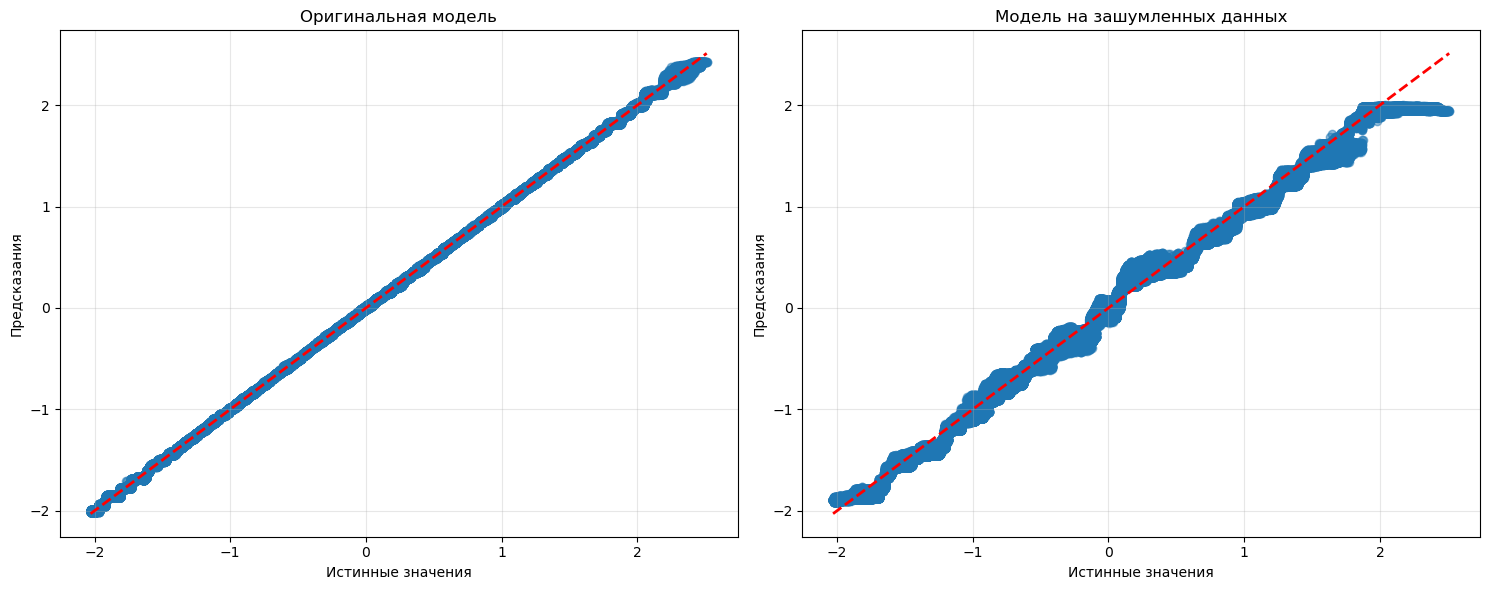


=== АНАЛИЗ УСТОЙЧИВОСТИ К ШУМУ ===
Шум std=0.1: RMSE=0.0225, R²=0.9995
Шум std=0.5: RMSE=0.0596, R²=0.9965
Шум std=1.0: RMSE=0.0932, R²=0.9913
Шум std=2.0: RMSE=0.1587, R²=0.9748


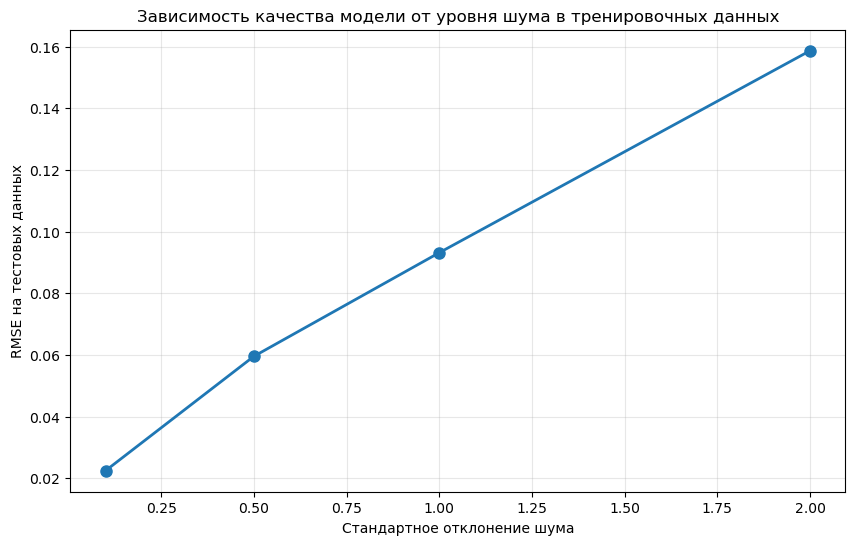

In [11]:
# 1. Сохранение лучшей модели
import joblib
import os

# Создаем папку для моделей если её нет
os.makedirs('./models', exist_ok=True)

# Сохраняем лучшую модель
model_path = './models/best_catboost_model_with_laplace.pkl'
joblib.dump(best_model, model_path)
print(f"Модель сохранена по пути: {model_path}")

# 2. Загрузка модели (пример)
def load_and_predict(model_path, X_data):
    """Загрузка модели и предсказание"""
    loaded_model = joblib.load(model_path)
    predictions = loaded_model.predict(X_data)
    return predictions, loaded_model

# Проверка загрузки модели
test_predictions, loaded_model = load_and_predict(model_path, X_test)
print(f"Проверка загрузки модели - RMSE: {np.sqrt(mean_squared_error(y_test, test_predictions)):.4f}")

# 3. Внесение случайной ошибки в целевую переменную тренировочных данных
def add_random_noise_to_target(y_data, mean=0, std=1, random_state=CFG.RANDOM_STATE):
    """Добавление гауссовского шума к целевой переменной"""
    np.random.seed(random_state)
    noise = np.random.normal(mean, std, len(y_data))
    return y_data + noise

# Добавляем шум к тренировочным данным
y_train_noisy = add_random_noise_to_target(y_train, mean=0, std=1)

print(f"Исходные данные - min: {y_train.min():.4f}, max: {y_train.max():.4f}, std: {y_train.std():.4f}")
print(f"Зашумленные данные - min: {y_train_noisy.min():.4f}, max: {y_train_noisy.max():.4f}, std: {y_train_noisy.std():.4f}")

# 4. Обучение модели на зашумленных данных для сравнения
print("\n=== ОБУЧЕНИЕ НА ЗАШУМЛЕННЫХ ДАННЫХ ===")

# Создание Pool с зашумленными данными
train_pool_noisy = Pool(X_train, y_train_noisy)
val_pool = Pool(X_test, y_test)  # Используем чистые данные для валидации

# Обучение модели на зашумленных данных
noisy_model = CatBoostRegressor(**best_params)
noisy_model.fit(
    train_pool_noisy,
    eval_set=val_pool,
    verbose=100,
    early_stopping_rounds=200
)

# Оценка модели на зашумленных данных
noisy_results = evaluate_model(noisy_model, X_test, y_test, coords_test, alpha=0.1)

print(f"Модель на зашумленных данных:")
print(f"Test RMSE: {noisy_results['rmse']:.4f}")
print(f"Test Laplace Loss: {noisy_results['laplace_loss']:.4f}")
print(f"Test R²: {noisy_results['r2']:.4f}")

# Сравнение с оригинальной моделью
print(f"\nСравнение с оригинальной моделью:")
print(f"Оригинальная RMSE: {test_results['rmse']:.4f} vs Зашумленная RMSE: {noisy_results['rmse']:.4f}")
print(f"Разница: {abs(test_results['rmse'] - noisy_results['rmse']):.4f}")

# 5. Сохранение модели, обученной на зашумленных данных
noisy_model_path = './models/catboost_model_noisy_data.pkl'
joblib.dump(noisy_model, noisy_model_path)
print(f"Модель на зашумленных данных сохранена по пути: {noisy_model_path}")

# 6. Визуализация сравнения предсказаний
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# прогноза оригинальной модели
ax1.scatter(y_test, test_results['predictions'], alpha=0.5)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax1.set_xlabel('Истинные значения')
ax1.set_ylabel('прогноза')
ax1.set_title('Оригинальная модель')
ax1.grid(True, alpha=0.3)

# прогноза модели на зашумленных данных
noisy_predictions = noisy_model.predict(X_test)
ax2.scatter(y_test, noisy_predictions, alpha=0.5)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax2.set_xlabel('Истинные значения')
ax2.set_ylabel('прогноза')
ax2.set_title('Модель на зашумленных данных')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./models/predictions_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 7. Анализ устойчивости модели к шуму
print("\n=== АНАЛИЗ УСТОЙЧИВОСТИ К ШУМУ ===")
noise_levels = [0.1, 0.5, 1.0, 2.0]  # Разные уровни шума
results_comparison = []

for noise_std in noise_levels:
    y_train_noisy_level = add_random_noise_to_target(y_train, mean=0, std=noise_std)
    
    model_noisy = CatBoostRegressor(**best_params)
    model_noisy.fit(
        Pool(X_train, y_train_noisy_level),
        eval_set=Pool(X_test, y_test),
        verbose=0,
        early_stopping_rounds=200
    )
    
    predictions = model_noisy.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    
    results_comparison.append({
        'noise_std': noise_std,
        'rmse': rmse,
        'r2': r2
    })
    
    print(f"Шум std={noise_std}: RMSE={rmse:.4f}, R²={r2:.4f}")

# Визуализация зависимости качества от уровня шума
plt.figure(figsize=(10, 6))
noise_stds = [r['noise_std'] for r in results_comparison]
rmses = [r['rmse'] for r in results_comparison]

plt.plot(noise_stds, rmses, 'o-', linewidth=2, markersize=8)
plt.xlabel('Стандартное отклонение шума')
plt.ylabel('RMSE на тестовых данных')
plt.title('Зависимость качества модели от уровня шума в тренировочных данных')
plt.grid(True, alpha=0.3)
plt.savefig('./models/noise_robustness_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


=== 3D ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ ===


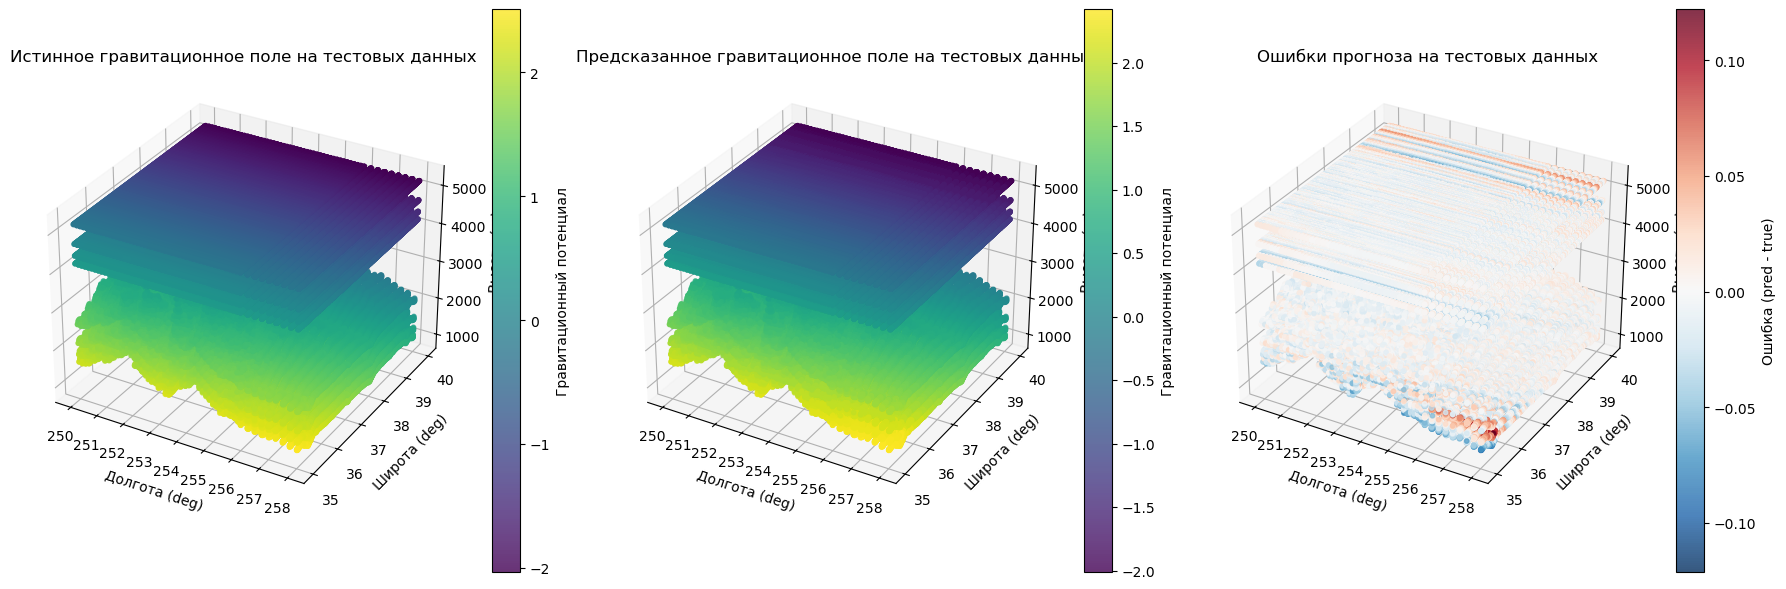

\nСтатистика ошибок:
Средняя ошибка: -0.0007
Стандартное отклонение ошибок: 0.0115
Максимальная ошибка: 0.1221
Минимальная ошибка: -0.1209
RMSE: 0.0116
\n=== 2D СРЕЗЫ ГРАВИТАЦИОННОГО ПОЛЯ ===


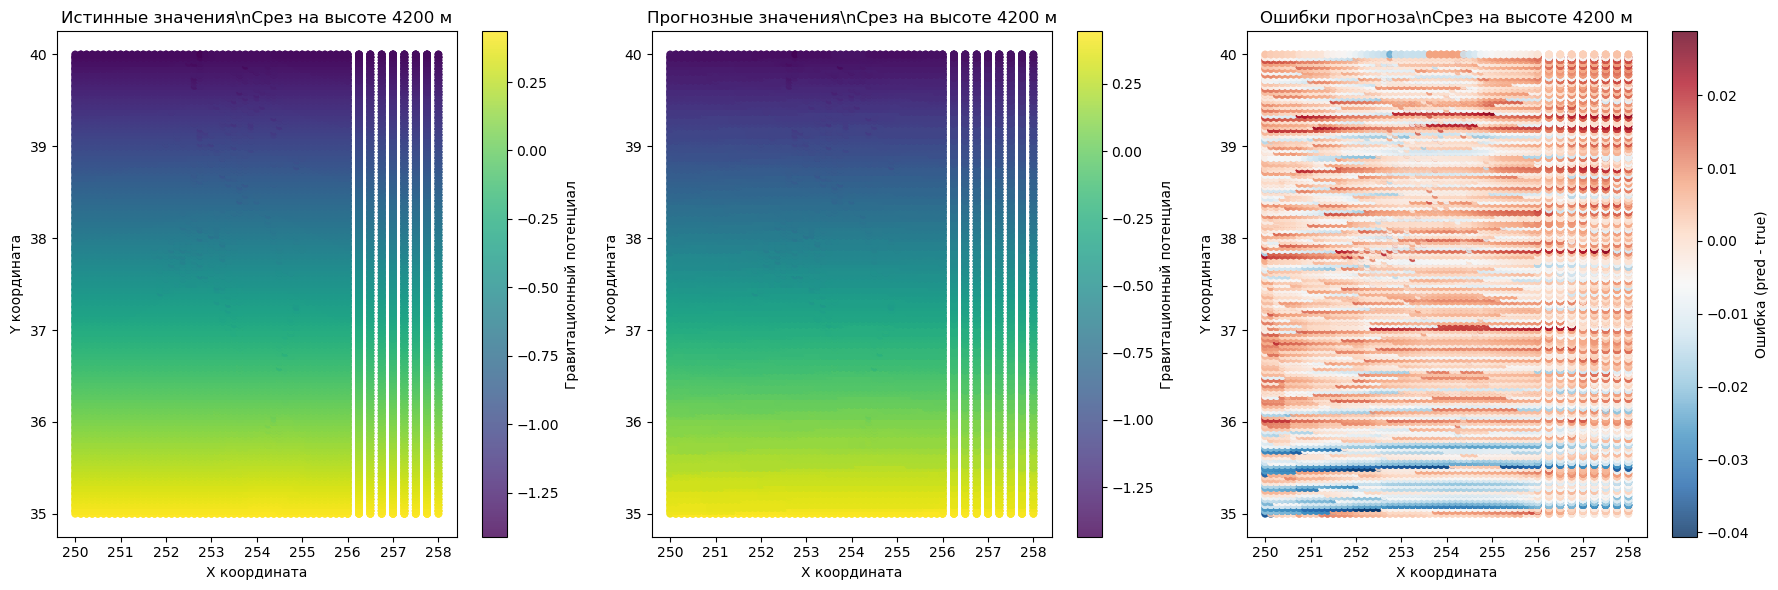

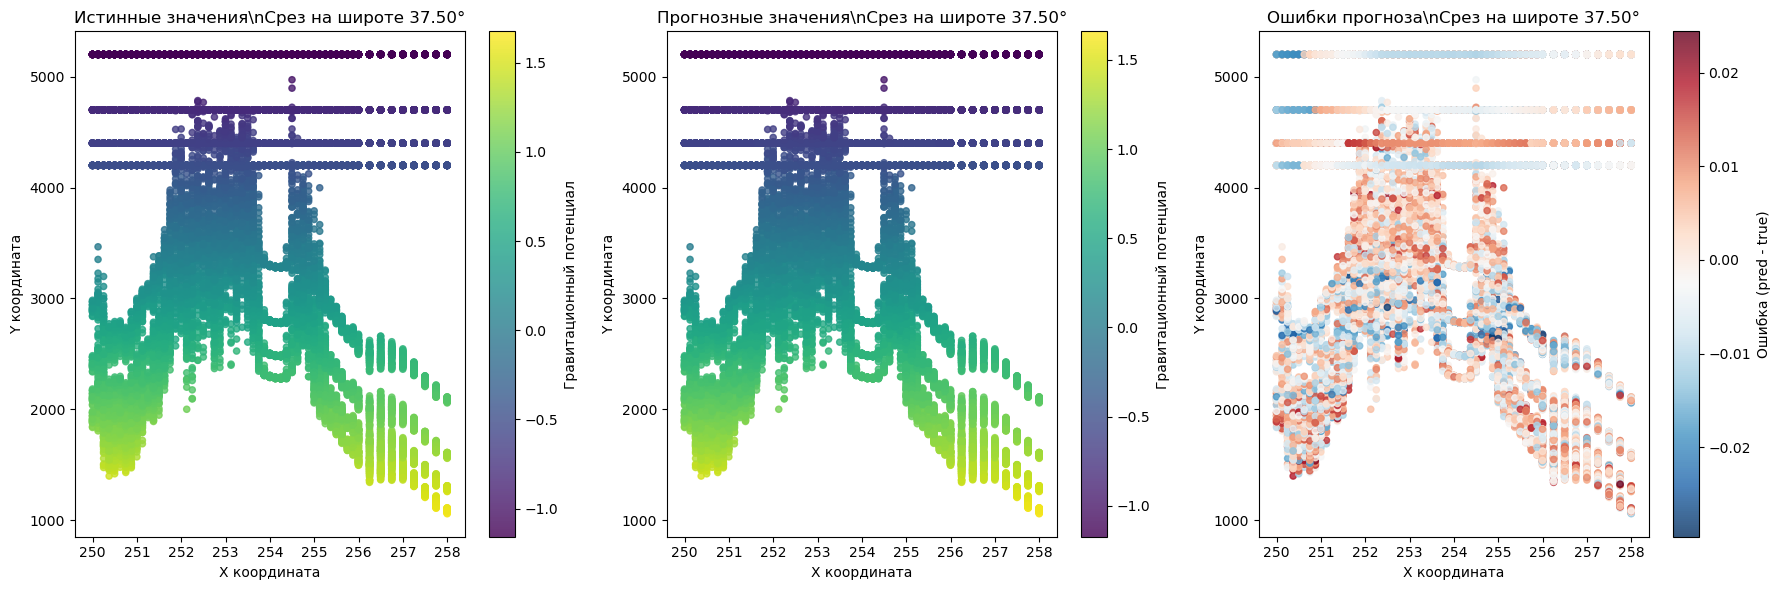

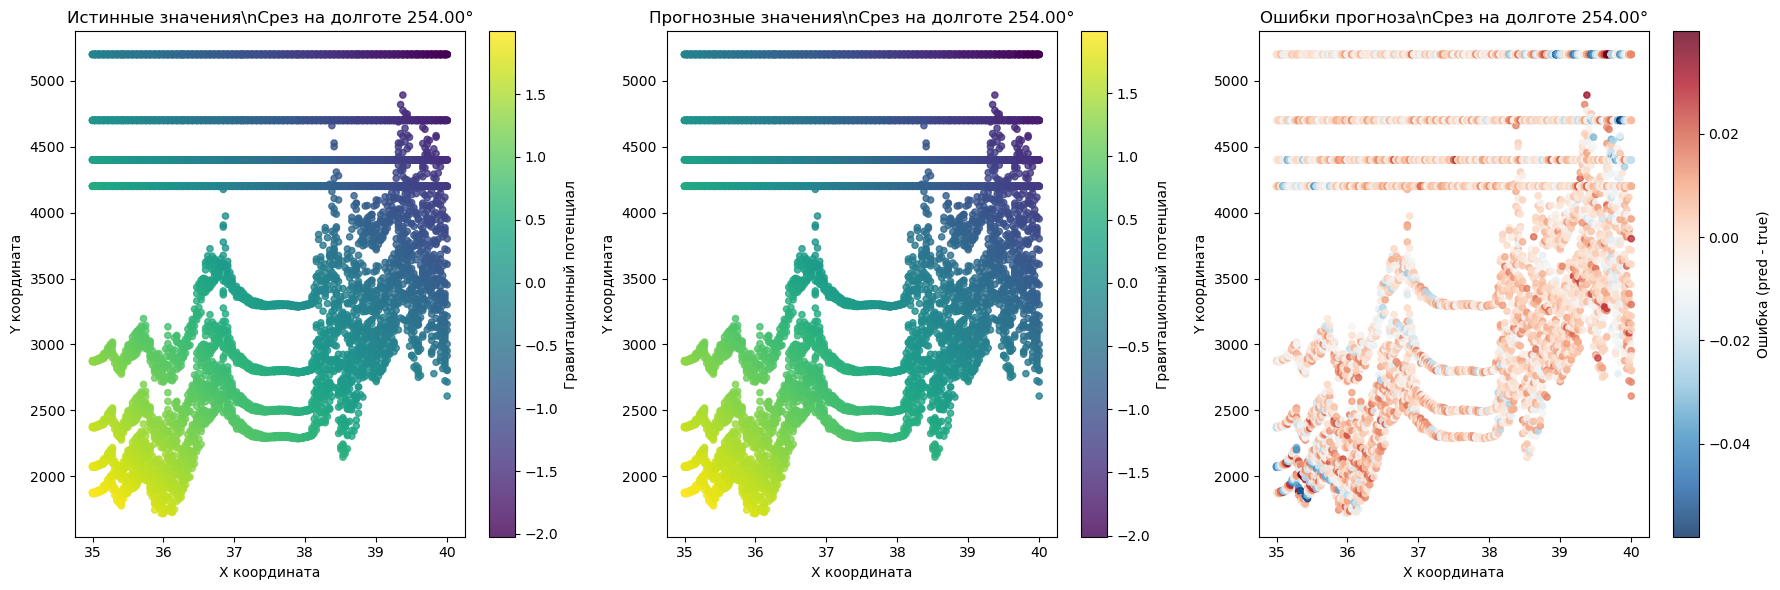

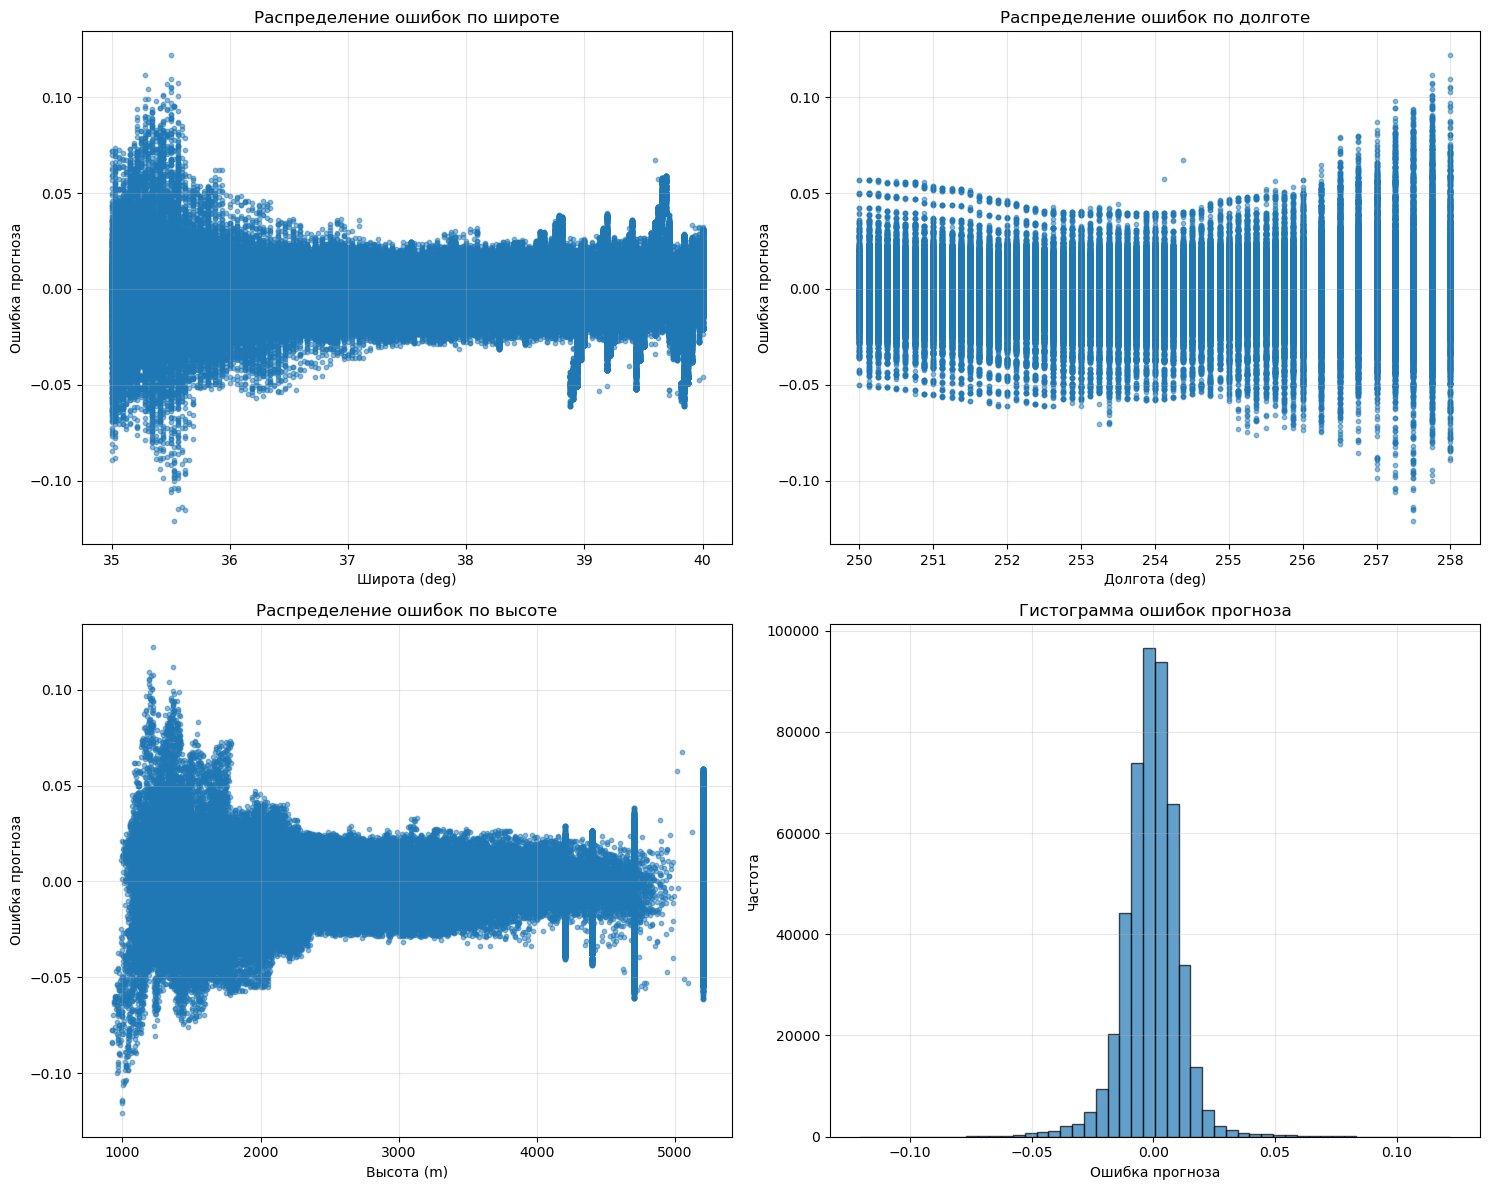

\nРезультаты сохранены:
RMSE: 0.0116
R²: 0.9999


In [17]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

def plot_3d_gravity_field(coords, true_values, pred_values, title_suffix=""):
    """
    Создает 3D визуализацию гравитационного поля
    """
    fig = plt.figure(figsize=(18, 6))
    
    # 1. Истинные значения
    ax1 = fig.add_subplot(131, projection='3d')
    scatter1 = ax1.scatter(coords[:, 1], coords[:, 0], coords[:, 2], 
                          c=true_values, cmap='viridis', s=10, alpha=0.8)
    ax1.set_xlabel('Долгота (deg)')
    ax1.set_ylabel('Широта (deg)')
    ax1.set_zlabel('Высота (m)')
    ax1.set_title(f'Истинное гравитационное поле {title_suffix}')
    fig.colorbar(scatter1, ax=ax1, label='Гравитационный потенциал')
    
    # 2. Прогнозные значения
    ax2 = fig.add_subplot(132, projection='3d')
    scatter2 = ax2.scatter(coords[:, 1], coords[:, 0], coords[:, 2], 
                          c=pred_values, cmap='viridis', s=10, alpha=0.8)
    ax2.set_xlabel('Долгота (deg)')
    ax2.set_ylabel('Широта (deg)')
    ax2.set_zlabel('Высота (m)')
    ax2.set_title(f'Предсказанное гравитационное поле {title_suffix}')
    fig.colorbar(scatter2, ax=ax2, label='Гравитационный потенциал')
    
    # 3. Ошибки прогноза
    errors = pred_values - true_values
    ax3 = fig.add_subplot(133, projection='3d')
    scatter3 = ax3.scatter(coords[:, 1], coords[:, 0], coords[:, 2], 
                          c=errors, cmap='RdBu_r', s=10, alpha=0.8)
    ax3.set_xlabel('Долгота (deg)')
    ax3.set_ylabel('Широта (deg)')
    ax3.set_zlabel('Высота (m)')
    ax3.set_title(f'Ошибки прогноза {title_suffix}')
    fig.colorbar(scatter3, ax=ax3, label='Ошибка (pred - true)')
    
    plt.tight_layout()
    plt.show()
    
    return errors

def plot_slice_comparison(coords, true_values, pred_values, slice_dim='height', slice_value=None):
    """
    Создает 2D срезы гравитационного поля
    """
    if slice_dim == 'height' and slice_value is None:
        slice_value = np.median(coords[:, 2])
    elif slice_dim == 'latitude' and slice_value is None:
        slice_value = np.median(coords[:, 0])
    elif slice_dim == 'longitude' and slice_value is None:
        slice_value = np.median(coords[:, 1])
    
    if slice_dim == 'height':
        mask = np.abs(coords[:, 2] - slice_value) < 100  # ±100 метров
        x = coords[mask, 1]  # долгота
        y = coords[mask, 0]  # широта
        title = f'Срез на высоте {slice_value:.0f} м'
    elif slice_dim == 'latitude':
        mask = np.abs(coords[:, 0] - slice_value) < 0.1  # ±0.1 градуса
        x = coords[mask, 1]  # долгота
        y = coords[mask, 2]  # высота
        title = f'Срез на широте {slice_value:.2f}°'
    elif slice_dim == 'longitude':
        mask = np.abs(coords[:, 1] - slice_value) < 0.1  # ±0.1 градуса
        x = coords[mask, 0]  # широта
        y = coords[mask, 2]  # высота
        title = f'Срез на долготе {slice_value:.2f}°'
    
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
    
    # Истинные значения
    sc1 = ax1.scatter(x, y, c=true_values[mask], cmap='viridis', s=20, alpha=0.8)
    ax1.set_title(f'Истинные значения\\n{title}')
    ax1.set_xlabel('X координата')
    ax1.set_ylabel('Y координата')
    plt.colorbar(sc1, ax=ax1, label='Гравитационный потенциал')
    
    # Прогнозные значения
    sc2 = ax2.scatter(x, y, c=pred_values[mask], cmap='viridis', s=20, alpha=0.8)
    ax2.set_title(f'Прогнозные значения\\n{title}')
    ax2.set_xlabel('X координата')
    ax2.set_ylabel('Y координата')
    plt.colorbar(sc2, ax=ax2, label='Гравитационный потенциал')
    
    # Ошибки
    errors = pred_values[mask] - true_values[mask]
    sc3 = ax3.scatter(x, y, c=errors, cmap='RdBu_r', s=20, alpha=0.8)
    ax3.set_title(f'Ошибки прогноза\\n{title}')
    ax3.set_xlabel('X координата')
    ax3.set_ylabel('Y координата')
    plt.colorbar(sc3, ax=ax3, label='Ошибка (pred - true)')
    
    plt.tight_layout()
    plt.show()

# ======== ДОБАВЬТЕ ЗДЕСЬ КОД ВИЗУАЛИЗАЦИИ ========
print("\n=== 3D ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ ===")

# Получаем прогноза
test_predictions = best_model.predict(X_test)

# Обратное масштабирование если нужно
if CFG.SCALE_TARGET:
    test_predictions_original = test_loader.scale_target(test_predictions, inverse=True)
    y_test_original = test_loader.scale_target(y_test.values, inverse=True)
else:
    test_predictions_original = test_predictions
    y_test_original = y_test.values

# Создаем 3D графики
errors = plot_3d_gravity_field(coords_test, y_test_original, test_predictions_original, 
                              "на тестовых данных")

# Анализ ошибок
print(f"\\nСтатистика ошибок:")
print(f"Средняя ошибка: {errors.mean():.4f}")
print(f"Стандартное отклонение ошибок: {errors.std():.4f}")
print(f"Максимальная ошибка: {errors.max():.4f}")
print(f"Минимальная ошибка: {errors.min():.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_original, test_predictions_original)):.4f}")

# 2D срезы для детального анализа
print("\\n=== 2D СРЕЗЫ ГРАВИТАЦИОННОГО ПОЛЯ ===")

# Срез по высоте
plot_slice_comparison(coords_test, y_test_original, test_predictions_original, 
                     'height', np.median(coords_test[:, 2]))

# Срез по широте
plot_slice_comparison(coords_test, y_test_original, test_predictions_original, 
                     'latitude', np.median(coords_test[:, 0]))

# Срез по долготе
plot_slice_comparison(coords_test, y_test_original, test_predictions_original, 
                     'longitude', np.median(coords_test[:, 1]))

# Дополнительная визуализация: распределение ошибок по координатам
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Распределение ошибок по широте
axes[0, 0].scatter(coords_test[:, 0], errors, alpha=0.5, s=10)
axes[0, 0].set_xlabel('Широта (deg)')
axes[0, 0].set_ylabel('Ошибка прогноза')
axes[0, 0].set_title('Распределение ошибок по широте')
axes[0, 0].grid(True, alpha=0.3)

# Распределение ошибок по долготе
axes[0, 1].scatter(coords_test[:, 1], errors, alpha=0.5, s=10)
axes[0, 1].set_xlabel('Долгота (deg)')
axes[0, 1].set_ylabel('Ошибка прогноза')
axes[0, 1].set_title('Распределение ошибок по долготе')
axes[0, 1].grid(True, alpha=0.3)

# Распределение ошибок по высоте
axes[1, 0].scatter(coords_test[:, 2], errors, alpha=0.5, s=10)
axes[1, 0].set_xlabel('Высота (m)')
axes[1, 0].set_ylabel('Ошибка прогноза')
axes[1, 0].set_title('Распределение ошибок по высоте')
axes[1, 0].grid(True, alpha=0.3)

# Гистограмма ошибок
axes[1, 1].hist(errors, bins=50, alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Ошибка прогноза')
axes[1, 1].set_ylabel('Частота')
axes[1, 1].set_title('Гистограмма ошибок прогноза')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./models/error_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Сохранение результатов визуализации
visualization_results = {
    'coordinates': coords_test,
    'true_values': y_test_original,
    'predicted_values': test_predictions_original,
    'errors': errors,
    'rmse': np.sqrt(mean_squared_error(y_test_original, test_predictions_original)),
    'r2': r2_score(y_test_original, test_predictions_original)
}

print(f"\\nРезультаты сохранены:")
print(f"RMSE: {visualization_results['rmse']:.4f}")
print(f"R²: {visualization_results['r2']:.4f}")